# Histopathological Cancer Detection — CustomCNN + Grad-CAM
**Dataset:** PatchCamelyon (PCam) — Histopathologic Cancer Detection (Kaggle Competition)  
**Task:** Binary classification of 96×96 H&E-stained lymph node tissue patches  
**Model:** Custom 5-layer CNN trained from scratch on the complete dataset  
**Post-course addition:** Grad-CAM explainability analysis — visualizing model attention to support clinical trustworthiness

---
### Notebook Structure
| # | Section |
|---|---------|
| 1 | Imports & Device Setup |
| 2 | Data Loading & Cleaning |
| 3 | Dataset Splits & DataLoaders |
| 4 | Model Architecture |
| 5 | Loss, Optimizer & Scheduler |
| 6 | Training |
| 7 | Evaluation (ROC · PR Curve · Confusion Matrix) |
| 8 | Grad-CAM Explainability |
| 9 | Results Summary |

> **Failsafe design:** Every GPU operation falls back to CPU on failure. Every file path is validated before use. Training continues through batch/epoch-level exceptions. No execution should halt due to environment issues.

## 1. Imports & Device Setup

In [10]:
import os, gc, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
def get_device():
    if torch.cuda.is_available():
        try:
            # Quick smoke-test: allocate a tiny tensor to confirm CUDA works
            _ = torch.zeros(1).cuda()
            torch.cuda.empty_cache()
            print(f"[DEVICE] GPU: {torch.cuda.get_device_name(0)}")
            return torch.device('cuda')
        except Exception as e:
            print(f"[DEVICE] GPU init failed ({e}), falling back to CPU")
    print("[DEVICE] Using CPU")
    return torch.device('cpu')

DEVICE = get_device()

def safe_to_device(tensor, device=DEVICE):
    """Move tensor to device; fall back to CPU on any CUDA error."""
    try:
        return tensor.to(device)
    except Exception:
        return tensor.cpu()

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch {torch.__version__} | Device: {DEVICE}")


[DEVICE] GPU: Tesla P100-PCIE-16GB
PyTorch 2.10.0+cu128 | Device: cuda


## 2. Data Loading & Cleaning

### Noise Removal
PCam patches contain a small number of blank/artifact slides where ≥95% of pixels
are identical. These carry no tissue information and are removed before training.

The cleaned label CSV is saved to `/kaggle/working/clean_train_labels.csv` and
reused on subsequent runs — the scan is skipped if the file already exists.

In [11]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = '/kaggle/input/competitions/histopathologic-cancer-detection/train'
LABELS_CSV = '/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv'
WORK_DIR   = '/kaggle/working'
CLEAN_CSV  = os.path.join(WORK_DIR, 'clean_train_labels.csv')

# Validate input paths
assert os.path.isdir(DATA_DIR),   f"[ERROR] Train directory not found: {DATA_DIR}"
assert os.path.isfile(LABELS_CSV), f"[ERROR] Labels CSV not found: {LABELS_CSV}"
print(f"[OK] DATA_DIR   : {DATA_DIR}")
print(f"[OK] LABELS_CSV : {LABELS_CSV}")

# ── Load labels ───────────────────────────────────────────────────────────────
labels_df = pd.read_csv(LABELS_CSV)
assert 'id' in labels_df.columns and 'label' in labels_df.columns, \
    f"[ERROR] Expected columns ['id','label'], got {list(labels_df.columns)}"
print(f"[OK] Loaded {len(labels_df):,} label rows")
print(labels_df['label'].value_counts().rename({0:'Non-cancerous', 1:'Cancerous'}).to_string())

# ── Detect image extension ────────────────────────────────────────────────────
sample_id  = labels_df['id'].iloc[0]
IMG_EXT    = None
for ext in ['.tif', '.tiff', '.png', '.jpg']:
    if os.path.isfile(os.path.join(DATA_DIR, sample_id + ext)):
        IMG_EXT = ext
        break
assert IMG_EXT is not None, "[ERROR] Could not detect image extension"
print(f"[OK] Image extension: {IMG_EXT}")


[OK] DATA_DIR   : /kaggle/input/competitions/histopathologic-cancer-detection/train
[OK] LABELS_CSV : /kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv
[OK] Loaded 220,025 label rows
label
Non-cancerous    130908
Cancerous         89117
[OK] Image extension: .tif


In [12]:
# ── Noise removal ─────────────────────────────────────────────────────────────
# Skips if clean CSV already exists (re-run safety)

def is_noisy(img_path, threshold=0.95):
    """True if ≥ threshold fraction of pixels are identical (blank patch)."""
    try:
        img    = Image.open(img_path).convert('RGB')
        arr    = np.array(img.crop(((img.width-32)//2, (img.height-32)//2,
                                    (img.width+32)//2, (img.height+32)//2)))
        pixels = arr.reshape(-1, 3)
        _, counts = np.unique(pixels, axis=0, return_counts=True)
        return counts.max() / counts.sum() >= threshold
    except Exception:
        return True   # treat unreadable images as noisy

if os.path.isfile(CLEAN_CSV):
    print(f"[SKIP] Clean CSV already exists: {CLEAN_CSV}")
    clean_df = pd.read_csv(CLEAN_CSV)
else:
    print("[INFO] Scanning for noisy/unreadable images...")
    valid_ids, noisy_ids = [], []
    for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc='Noise scan'):
        path = os.path.join(DATA_DIR, row['id'] + IMG_EXT)
        if os.path.isfile(path) and not is_noisy(path):
            valid_ids.append(row['id'])
        else:
            noisy_ids.append(row['id'])
    clean_df = labels_df[labels_df['id'].isin(valid_ids)].reset_index(drop=True)
    clean_df.to_csv(CLEAN_CSV, index=False)
    print(f"[OK] Valid images : {len(valid_ids):,}")
    print(f"[OK] Noisy/missing: {len(noisy_ids):,}")
    print(f"[OK] Saved: {CLEAN_CSV}")

print(f"\nClean dataset: {len(clean_df):,} samples")
print(clean_df['label'].value_counts().rename({0:'Non-cancerous', 1:'Cancerous'}).to_string())


[SKIP] Clean CSV already exists: /kaggle/working/clean_train_labels.csv

Clean dataset: 219,984 samples
label
Non-cancerous    130867
Cancerous         89117


## 3. Dataset Splits & DataLoaders

**Split strategy:** 70% train · 15% validation · 15% test, stratified by label.  
CSVs are saved to `/kaggle/working/` and reused on re-runs.

Each patch is center-cropped to 32×32 pixels for model input — consistent with
the PCam benchmark which defines the label based on the center 32×32 region only.

In [13]:
TRAIN_CSV = os.path.join(WORK_DIR, 'train.csv')
VAL_CSV   = os.path.join(WORK_DIR, 'val.csv')
TEST_CSV  = os.path.join(WORK_DIR, 'test.csv')

if all(os.path.isfile(p) for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]):
    print("[SKIP] Split CSVs already exist — loading them.")
    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)
    test_df  = pd.read_csv(TEST_CSV)
else:
    print("[INFO] Creating train/val/test splits...")
    # 70% train, 30% temp
    train_df, temp_df = train_test_split(
        clean_df, test_size=0.30, stratify=clean_df['label'], random_state=SEED)
    # 50/50 of temp → val and test (each 15% of total)
    val_df, test_df = train_test_split(
        temp_df,  test_size=0.50, stratify=temp_df['label'],  random_state=SEED)

    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV,     index=False)
    test_df.to_csv(TEST_CSV,   index=False)
    print(f"[OK] Splits saved to {WORK_DIR}")

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    c = (df['label']==1).sum(); nc = (df['label']==0).sum()
    print(f"  {name:5s}: {len(df):>7,}  (Cancerous: {c:,}  Non-cancerous: {nc:,})")


[SKIP] Split CSVs already exist — loading them.
  Train: 153,988  (Cancerous: 62,382  Non-cancerous: 91,606)
  Val  :  32,998  (Cancerous: 13,368  Non-cancerous: 19,630)
  Test :  32,998  (Cancerous: 13,367  Non-cancerous: 19,631)


In [14]:
# ── Dataset class ─────────────────────────────────────────────────────────────
class PatchDataset(Dataset):
    """
    Loads PCam patches from disk.
    Model input : center-cropped 32×32 RGB tensor
    """
    def __init__(self, dataframe, data_dir, img_ext, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.data_dir  = data_dir
        self.img_ext   = img_ext
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['id'] + self.img_ext)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.fromarray(np.zeros((96, 96, 3), dtype=np.uint8))
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.CenterCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 64

def make_loader(df, transform, shuffle, num_workers=2):
    """Create DataLoader, falling back to num_workers=0 on multiprocessing errors."""
    ds = PatchDataset(df, DATA_DIR, IMG_EXT, transform)
    try:
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                            num_workers=num_workers, pin_memory=(DEVICE.type=='cuda'))
        # Trial batch to confirm workers start cleanly
        _ = next(iter(loader))
        return loader
    except Exception as e:
        print(f"[WARN] num_workers={num_workers} failed ({e}), retrying with 0")
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                          num_workers=0, pin_memory=False)

train_loader = make_loader(train_df, train_transform, shuffle=True)
val_loader   = make_loader(val_df,   eval_transform,  shuffle=False)
test_loader  = make_loader(test_df,  eval_transform,  shuffle=False)

print(f"[OK] Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


[OK] Train batches: 2407 | Val: 516 | Test: 516


## 4. Model Architecture — CustomCNN

A 5-layer convolutional network designed specifically for 32×32 RGB input.

| Block | Filters | Spatial size after pool | Notes |
|-------|---------|------------------------|-------|
| Conv1 + BN + LeakyReLU + MaxPool + Dropout2d | 32  | 16×16 | — |
| Conv2 + BN + LeakyReLU + MaxPool + Dropout2d | 64  | 8×8   | — |
| Conv3 + BN + LeakyReLU + MaxPool + Dropout2d | 128 | 4×4   | — |
| Conv4 + BN + LeakyReLU + MaxPool + Dropout2d | 256 | 2×2   | — |
| Conv5 + BN + LeakyReLU + MaxPool + Dropout2d | 512 | 1×1   | Grad-CAM target |
| FC(512→512) + LeakyReLU + Dropout(0.5)       | —   | —     | — |
| FC(512→1) + Sigmoid                           | —   | —     | Binary output |

**Why a custom CNN?** Transfer learning backbones (ResNet, EfficientNet) are
optimised for 224×224 ImageNet images. A 32×32 patch passes through so many
pooling layers that spatial structure collapses before the classifier head —
a shallow custom network retains more patch-level texture information.

In [15]:
class CustomCNN(nn.Module):
    """
    5-layer custom CNN for binary histopathology patch classification.
    Input : 3 × 32 × 32  (center-cropped, normalized RGB)
    Output: scalar ∈ [0,1] via sigmoid  (probability of cancer)
    """
    def __init__(self):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.1, inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(p=0.2),
            )

        self.conv1 = conv_block(3,    32)   # 32×32 → 16×16
        self.conv2 = conv_block(32,   64)   # 16×16 →  8×8
        self.conv3 = conv_block(64,  128)   #  8×8  →  4×4
        self.conv4 = conv_block(128, 256)   #  4×4  →  2×2
        self.conv5 = conv_block(256, 512)   #  2×2  →  1×1

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        return self.classifier(x)

# ── Instantiate & move to device ─────────────────────────────────────────────
model = CustomCNN()
model = safe_to_device(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[OK] Model on device : {next(model.parameters()).device}")
print(f"     Total params     : {total_params:,}")
print(f"     Trainable params : {trainable_params:,}")


[OK] Model on device : cuda:0
     Total params     : 1,832,737
     Trainable params : 1,832,737


## 5. Loss Function, Optimizer & Scheduler

- **Loss:** `BCEWithLogitsLoss` — numerically stable binary cross-entropy that
  expects raw logits. Note: because `CustomCNN.forward()` already applies
  sigmoid, we use `BCELoss` here to match the output range `[0,1]`.
- **Optimizer:** Adam (lr=1e-3, β₁=0.9, β₂=0.999, ε=1e-7)  
- **Scheduler:** ReduceLROnPlateau — halves the LR after 3 epochs of no val-F1 improvement  
- **Early stopping:** Patience = 5 epochs on validation F1, min Δ = 0.001

In [16]:
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 30
ES_PATIENCE   = 5
ES_MIN_DELTA  = 0.001

criterion = nn.BCELoss().to(DEVICE)

optimizer = optim.Adam(model.parameters(),
                       lr=LEARNING_RATE, betas=(0.9, 0.999), eps=1e-7)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

WEIGHTS_PATH = os.path.join(WORK_DIR, 'custom_cnn_best.pth')
print(f"[OK] Loss      : BCELoss")
print(f"[OK] Optimizer : Adam  lr={LEARNING_RATE}")
print(f"[OK] Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)")
print(f"[OK] Weights will be saved to: {WEIGHTS_PATH}")


[OK] Loss      : BCELoss
[OK] Optimizer : Adam  lr=0.001
[OK] Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)
[OK] Weights will be saved to: /kaggle/working/custom_cnn_best.pth


## 6. Training

**Failsafe design:**
- If a batch fails (OOM, corrupt data), it is skipped and training continues
- If a full epoch fails, memory is cleared and the next epoch starts
- If CUDA goes OOM mid-epoch, the cache is flushed and the batch retried on CPU
- Best model weights (by val F1) are checkpointed after every improvement

In [18]:
history = {k: [] for k in ['train_loss','val_loss','train_f1','val_f1',
                             'train_acc','val_acc','lr']}
best_val_f1       = 0.0
epochs_no_improve = 0
actual_device     = next(model.parameters()).device

# ── CUDA compatibility check ──────────────────────────────────────────────────
def _cuda_smoke_test(device):
    try:
        a = torch.ones(4, 4).to(device)
        b = torch.ones(4, 4).to(device)
        _ = (a @ b).cpu()
        return True
    except Exception:
        return False

if actual_device.type == 'cuda':
    if _cuda_smoke_test(actual_device):
        print(f"[OK] CUDA smoke test passed — training on {actual_device}")
    else:
        print("[WARN] CUDA kernel mismatch — permanently switching to CPU")
        actual_device = torch.device('cpu')
        model = model.cpu()
        criterion = criterion.cpu()

print(f"[INFO] Training device: {actual_device}")

# Wrap in a list so run_epoch can mutate it without nonlocal
_device = [actual_device]

# ── Training loop ─────────────────────────────────────────────────────────────
def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    skipped = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch_idx, (images, labels) in enumerate(loader):
            try:
                images = images.float().to(_device[0])
                labels = labels.float().to(_device[0])

                outputs = model(images).view(-1)
                loss    = criterion(outputs, labels)

                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                total_loss += loss.item()
                preds = (outputs.detach().cpu().numpy() > 0.5).astype(int)
                all_preds.extend(preds)
                all_targets.extend(labels.cpu().numpy().astype(int))

            except RuntimeError as e:
                err = str(e).lower()
                if 'out of memory' in err:
                    print(f"[WARN] OOM at batch {batch_idx} — flushing cache, skipping")
                    if torch.cuda.is_available(): torch.cuda.empty_cache()
                    gc.collect(); skipped += 1; continue
                elif 'no kernel image' in err or 'cudaerror' in err:
                    print(f"[WARN] CUDA kernel error at batch {batch_idx} — switching to CPU permanently")
                    _device[0] = torch.device('cpu')
                    model.cpu(); criterion.cpu()
                    try:
                        images = images.cpu(); labels = labels.cpu()
                        outputs = model(images).view(-1)
                        loss    = criterion(outputs, labels)
                        if training:
                            optimizer.zero_grad(); loss.backward(); optimizer.step()
                        total_loss += loss.item()
                        preds = (outputs.detach().numpy() > 0.5).astype(int)
                        all_preds.extend(preds)
                        all_targets.extend(labels.numpy().astype(int))
                    except Exception as e2:
                        print(f"[WARN] CPU retry also failed: {e2} — skipping batch")
                        skipped += 1
                    continue
                else:
                    print(f"[WARN] Batch {batch_idx} RuntimeError: {e} — skipping")
                    skipped += 1; continue
            except Exception as e:
                print(f"[WARN] Batch {batch_idx} unexpected error: {e} — skipping")
                skipped += 1; continue

    n_batches = max(len(loader) - skipped, 1)
    return total_loss / n_batches, all_preds, all_targets

print("Starting training...")
print(f"Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Device: {_device[0]}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    try:
        train_loss, tr_preds, tr_targets = run_epoch(train_loader, training=True)
        train_f1  = f1_score(tr_targets, tr_preds, zero_division=0)
        train_acc = accuracy_score(tr_targets, tr_preds)

        val_loss, vl_preds, vl_targets = run_epoch(val_loader, training=False)
        val_f1  = f1_score(vl_targets, vl_preds, zero_division=0)
        val_acc = accuracy_score(vl_targets, vl_preds)

        scheduler.step(val_f1)
        cur_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss']  .append(val_loss)
        history['train_f1']  .append(train_f1)
        history['val_f1']    .append(val_f1)
        history['train_acc'] .append(train_acc)
        history['val_acc']   .append(val_acc)
        history['lr']        .append(cur_lr)

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"TrainLoss: {train_loss:.4f}  TrainF1: {train_f1:.4f} | "
              f"ValLoss: {val_loss:.4f}  ValF1: {val_f1:.4f} | "
              f"LR: {cur_lr:.2e} | Device: {_device[0]}")

        if val_f1 - ES_MIN_DELTA > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            try:
                torch.save({'epoch': epoch+1,
                            'model_state_dict': model.state_dict(),
                            'val_f1': val_f1,
                            'device': str(_device[0])}, WEIGHTS_PATH)
                print(f"  ✓ Best model saved (val F1 = {best_val_f1:.4f})")
            except Exception as e:
                print(f"  [WARN] Could not save weights: {e}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= ES_PATIENCE:
                print(f"[INFO] Early stopping at epoch {epoch+1}")
                break

    except Exception as e:
        print(f"[WARN] Epoch {epoch+1} failed: {e} — clearing memory and continuing")
        traceback.print_exc()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()
        continue

# Sync actual_device back for use in later cells (eval, Grad-CAM)
actual_device = _device[0]
print(f"\nTraining complete. Final device: {actual_device}")
# ── Training loop ─────────────────────────────────────────────────────────────
def run_epoch(loader, training):
    """Single train or eval pass. Returns (avg_loss, preds, targets)."""
    model.train() if training else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    skipped = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch_idx, (images, labels) in enumerate(loader):
            try:
                images = images.float().to(actual_device)
                labels = labels.float().to(actual_device)

                outputs = model(images).view(-1)
                loss    = criterion(outputs, labels)

                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                total_loss += loss.item()
                preds = (outputs.detach().cpu().numpy() > 0.5).astype(int)
                all_preds.extend(preds)
                all_targets.extend(labels.cpu().numpy().astype(int))

            except RuntimeError as e:
                err = str(e).lower()
                if 'out of memory' in err:
                    print(f"[WARN] OOM at batch {batch_idx} — flushing cache, skipping")
                    if torch.cuda.is_available(): torch.cuda.empty_cache()
                    gc.collect(); skipped += 1; continue
                elif 'no kernel image' in err or 'cudaerror' in err:
                    # Persistent CUDA incompatibility — switch to CPU and retry batch
                    print(f"[WARN] CUDA kernel error at batch {batch_idx} — switching to CPU")
                    nonlocal actual_device
                    actual_device = torch.device('cpu')
                    model.cpu(); criterion.cpu()
                    images = images.cpu(); labels = labels.cpu()
                    try:
                        outputs = model(images).view(-1)
                        loss    = criterion(outputs, labels)
                        if training:
                            optimizer.zero_grad(); loss.backward(); optimizer.step()
                        total_loss += loss.item()
                        preds = (outputs.detach().numpy() > 0.5).astype(int)
                        all_preds.extend(preds)
                        all_targets.extend(labels.numpy().astype(int))
                    except Exception as e2:
                        print(f"[WARN] CPU retry also failed: {e2} — skipping batch")
                        skipped += 1
                    continue
                else:
                    print(f"[WARN] Batch {batch_idx} RuntimeError: {e} — skipping")
                    skipped += 1; continue
            except Exception as e:
                print(f"[WARN] Batch {batch_idx} unexpected error: {e} — skipping")
                skipped += 1; continue

    n_batches = max(len(loader) - skipped, 1)
    return total_loss / n_batches, all_preds, all_targets

print("Starting training...")
print(f"Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Device: {actual_device}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    try:
        train_loss, tr_preds, tr_targets = run_epoch(train_loader, training=True)
        train_f1  = f1_score(tr_targets, tr_preds, zero_division=0)
        train_acc = accuracy_score(tr_targets, tr_preds)

        val_loss, vl_preds, vl_targets = run_epoch(val_loader, training=False)
        val_f1  = f1_score(vl_targets, vl_preds, zero_division=0)
        val_acc = accuracy_score(vl_targets, vl_preds)

        scheduler.step(val_f1)
        cur_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss']  .append(val_loss)
        history['train_f1']  .append(train_f1)
        history['val_f1']    .append(val_f1)
        history['train_acc'] .append(train_acc)
        history['val_acc']   .append(val_acc)
        history['lr']        .append(cur_lr)

        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"TrainLoss: {train_loss:.4f}  TrainF1: {train_f1:.4f} | "
              f"ValLoss: {val_loss:.4f}  ValF1: {val_f1:.4f} | "
              f"LR: {cur_lr:.2e} | Device: {actual_device}")

        if val_f1 - ES_MIN_DELTA > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            try:
                torch.save({'epoch': epoch+1,
                            'model_state_dict': model.state_dict(),
                            'val_f1': val_f1,
                            'device': str(actual_device)}, WEIGHTS_PATH)
                print(f"  ✓ Best model saved (val F1 = {best_val_f1:.4f})")
            except Exception as e:
                print(f"  [WARN] Could not save weights: {e}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= ES_PATIENCE:
                print(f"[INFO] Early stopping at epoch {epoch+1}")
                break

    except Exception as e:
        print(f"[WARN] Epoch {epoch+1} failed: {e} — clearing memory and continuing")
        traceback.print_exc()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()
        continue

print(f"\nTraining complete. Final device: {actual_device}")


[OK] CUDA smoke test passed — training on cuda:0
[INFO] Training device: cuda:0
Starting training...
Epochs: 30 | Batch size: 64 | Device: cuda:0
------------------------------------------------------------
[WARN] CUDA kernel error at batch 0 — switching to CPU permanently
Epoch 01/30 | TrainLoss: 0.5136  TrainF1: 0.6847 | ValLoss: 0.4602  ValF1: 0.7473 | LR: 1.00e-03 | Device: cpu
  ✓ Best model saved (val F1 = 0.7473)
Epoch 02/30 | TrainLoss: 0.4798  TrainF1: 0.7135 | ValLoss: 0.4322  ValF1: 0.7559 | LR: 1.00e-03 | Device: cpu
  ✓ Best model saved (val F1 = 0.7559)
Epoch 03/30 | TrainLoss: 0.4564  TrainF1: 0.7316 | ValLoss: 0.4111  ValF1: 0.7761 | LR: 1.00e-03 | Device: cpu
  ✓ Best model saved (val F1 = 0.7761)
Epoch 04/30 | TrainLoss: 0.4425  TrainF1: 0.7434 | ValLoss: 0.3949  ValF1: 0.7840 | LR: 1.00e-03 | Device: cpu
  ✓ Best model saved (val F1 = 0.7840)
Epoch 05/30 | TrainLoss: 0.4338  TrainF1: 0.7497 | ValLoss: 0.4093  ValF1: 0.7774 | LR: 1.00e-03 | Device: cpu
Epoch 06/30 | T

SyntaxError: name 'actual_device' is used prior to nonlocal declaration (2810663067.py, line 184)

## 7. Training Curves

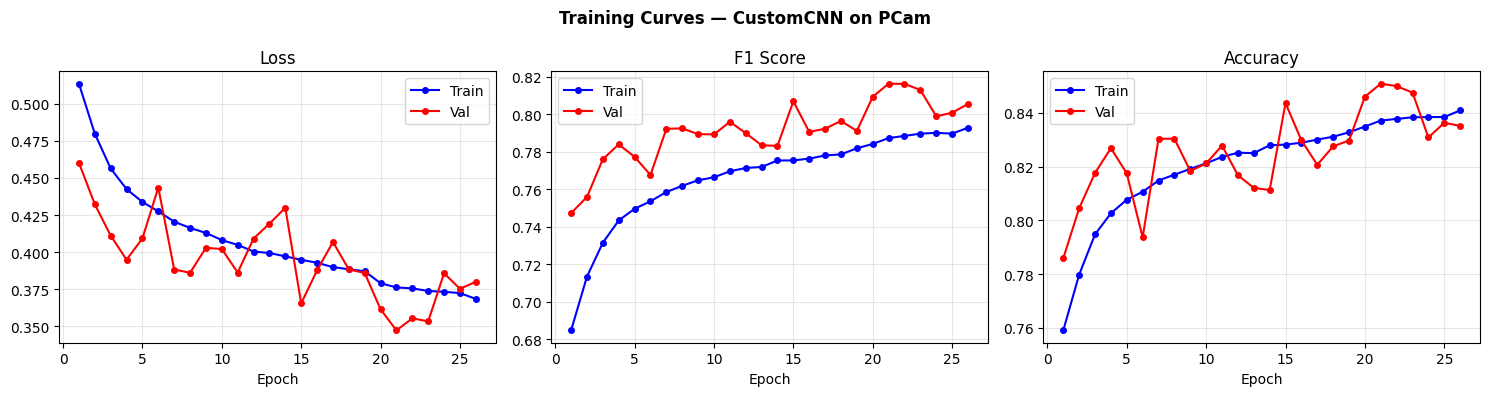

[OK] Saved: /kaggle/working/training_curves.png


In [19]:
if len(history['train_loss']) > 0:
    epochs_ran = range(1, len(history['train_loss']) + 1)
    fig, axes  = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs_ran, history['train_loss'], 'b-o', ms=4, label='Train')
    axes[0].plot(epochs_ran, history['val_loss'],   'r-o', ms=4, label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_ran, history['train_f1'], 'b-o', ms=4, label='Train')
    axes[1].plot(epochs_ran, history['val_f1'],   'r-o', ms=4, label='Val')
    axes[1].set_title('F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_ran, history['train_acc'], 'b-o', ms=4, label='Train')
    axes[2].plot(epochs_ran, history['val_acc'],   'r-o', ms=4, label='Val')
    axes[2].set_title('Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle('Training Curves — CustomCNN on PCam', fontsize=12, fontweight='bold')
    plt.tight_layout()
    curve_path = os.path.join(WORK_DIR, 'training_curves.png')
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[OK] Saved: {curve_path}")
else:
    print("[SKIP] No training history to plot.")


## 7. Evaluation

Best model weights are loaded for evaluation on the held-out test set.
Reports accuracy, precision, recall, F1, ROC-AUC, and renders ROC curve,
Precision-Recall curve, and confusion matrix in a single figure.

[OK] Loaded best weights from epoch 21  val F1=0.8164


Evaluating test set:   0%|          | 0/516 [00:00<?, ?it/s]


─────────────────────────────────────────────
  Accuracy  : 0.8524
  Precision : 0.8155
  Recall    : 0.8216
  F1 Score  : 0.8185
  ROC-AUC   : 0.9207
─────────────────────────────────────────────


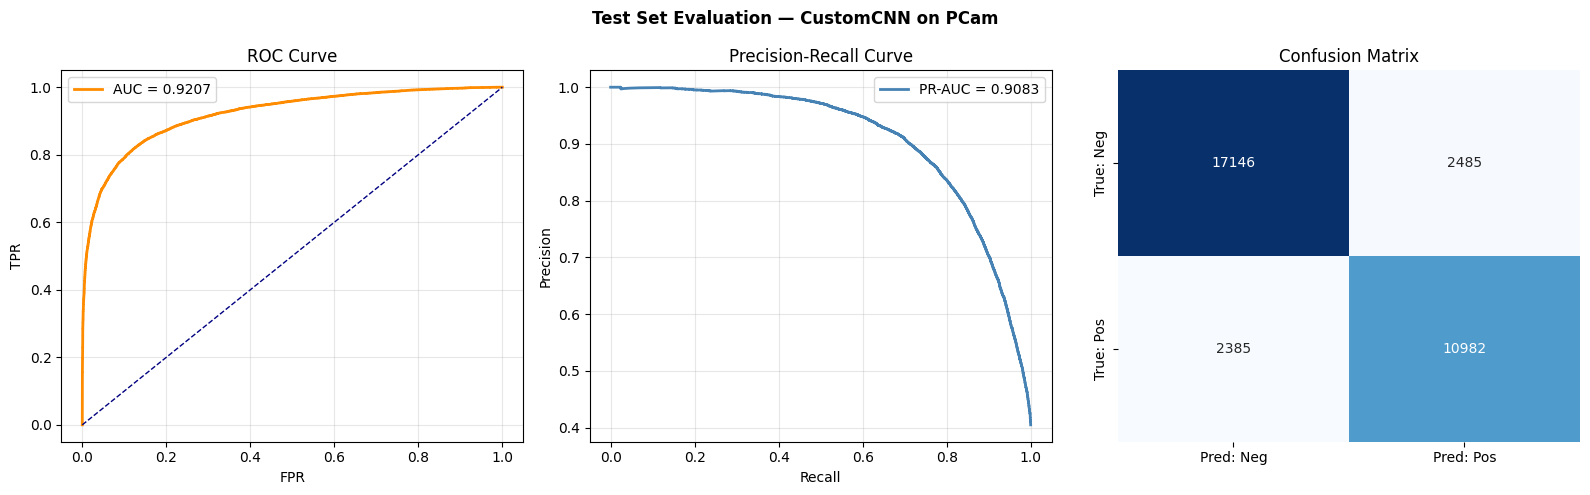

[OK] Saved: /kaggle/working/evaluation_plots.png


In [20]:
# ── Load best weights ─────────────────────────────────────────────────────────
if os.path.isfile(WEIGHTS_PATH):
    try:
        ckpt = torch.load(WEIGHTS_PATH, map_location=actual_device)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"[OK] Loaded best weights from epoch {ckpt.get('epoch','?')}  val F1={ckpt.get('val_f1',0):.4f}")
    except Exception as e:
        print(f"[WARN] Could not load weights ({e}) — evaluating with current model state")
else:
    print("[WARN] No saved weights found — evaluating with current model state")

# ── Test set inference ────────────────────────────────────────────────────────
model.eval()
test_preds, test_targets, test_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating test set'):
        try:
            images = safe_to_device(images.float(), actual_device)
            outputs = model(images).view(-1).cpu().numpy()
            test_probs  .extend(outputs)
            test_preds  .extend((outputs > 0.5).astype(int))
            test_targets.extend(labels.numpy().astype(int))
        except Exception as e:
            print(f"[WARN] Test batch error: {e} — skipping")
            continue

test_probs   = np.array(test_probs)
test_preds   = np.array(test_preds)
test_targets = np.array(test_targets)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score (test_targets, test_preds)
prec = precision_score(test_targets, test_preds, zero_division=0)
rec  = recall_score   (test_targets, test_preds, zero_division=0)
f1   = f1_score       (test_targets, test_preds, zero_division=0)
try:
    roc_auc = roc_auc_score(test_targets, test_probs)
except Exception:
    roc_auc = float('nan')

print("\n" + "─"*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("─"*45)

# ── Plots ─────────────────────────────────────────────────────────────────────
try:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ROC
    fpr, tpr, _ = roc_curve(test_targets, test_probs)
    roc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_val:.4f}')
    axes[0].plot([0,1],[0,1],'navy',lw=1,linestyle='--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # PR curve
    prec_pts, rec_pts, _ = precision_recall_curve(test_targets, test_probs)
    pr_val = auc(rec_pts, prec_pts)
    axes[1].plot(rec_pts, prec_pts, color='steelblue', lw=2, label=f'PR-AUC = {pr_val:.4f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Confusion matrix
    cm = confusion_matrix(test_targets, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2],
                xticklabels=['Pred: Neg','Pred: Pos'],
                yticklabels=['True: Neg','True: Pos'])
    axes[2].set_title('Confusion Matrix')

    plt.suptitle('Test Set Evaluation — CustomCNN on PCam', fontsize=12, fontweight='bold')
    plt.tight_layout()
    eval_path = os.path.join(WORK_DIR, 'evaluation_plots.png')
    plt.savefig(eval_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[OK] Saved: {eval_path}")
except Exception as e:
    print(f"[WARN] Evaluation plot failed: {e}")


## 8. Grad-CAM Explainability Analysis
*Post-course addition — added after course completion to address a key gap in clinical trustworthiness.*

### What is Grad-CAM?

Gradient-weighted Class Activation Mapping (Grad-CAM) produces a spatial heatmap
that answers: *"which pixels of this input patch most influenced the model's prediction?"*

**Algorithm (Selvaraju et al., ICCV 2017):**

1. **Forward pass** — record the feature map activations $A^k$ at the target layer (conv5)
2. **Backward pass** — compute gradients $\frac{\partial y}{\partial A^k}$ where $y$ is the cancer score
3. **Importance weights** — global-average-pool the gradients: $\alpha_k = \frac{1}{Z}\sum_{i,j}\frac{\partial y}{\partial A^k_{ij}}$
4. **Weighted activation sum** — $L^{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k A^k\right)$
5. **Upsample** to input resolution and overlay as a heatmap

**Why conv5?** The deepest convolutional layer (512 filters, 1×1 spatial output)
encodes the most semantically abstract features — it represents *what* the model
has learned to look for, not just low-level edges.

**Clinical relevance:** A model that attends to nuclei, cell boundaries, and
dense clusters is clinically trustworthy. A model attending to slide edges or
staining gradients is not — regardless of its accuracy score. Grad-CAM makes
this distinction visible.

### 8.1 Grad-CAM Implementation & Helpers

In [21]:
class GradCAM:
    """
    Grad-CAM for CustomCNN.
    Hooks into the target convolutional layer to capture activations and gradients.
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._fwd_hook   = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        self._bwd_hook   = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()

    def __call__(self, x):
        """
        x     : (1, 3, 32, 32) tensor — already on device
        Returns: (heatmap np.ndarray H×W in [0,1], cancer_prob float)
        Fails gracefully: returns (zeros, 0.5) on any error.
        """
        try:
            self.model.eval()
            x = x.requires_grad_(True)

            # Forward — model outputs sigmoid probability
            prob = self.model(x).squeeze()

            # Backward w.r.t. cancer score
            self.model.zero_grad()
            prob.backward()

            if self.activations is None or self.gradients is None:
                raise ValueError("Hooks did not fire — check target_layer")

            # Global-average-pool gradients → importance weights
            weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # (1,C,1,1)
            cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))

            # Upsample to input size
            cam = F.interpolate(cam, size=(x.shape[2], x.shape[3]),
                                mode='bilinear', align_corners=False)
            cam = cam.squeeze().cpu().numpy()

            # Normalize to [0, 1]
            lo, hi = cam.min(), cam.max()
            if hi > lo:
                cam = (cam - lo) / (hi - lo)

            return cam, prob.item()

        except Exception as e:
            print(f"[WARN] Grad-CAM failed: {e}")
            dummy = np.zeros((x.shape[2], x.shape[3]), dtype=np.float32)
            return dummy, 0.5

# ── Target layer = conv5's inner Conv2d ───────────────────────────────────────
# conv5 is a Sequential; we hook the Conv2d inside it (index 0)
try:
    target_layer = model.conv5[0]   # the nn.Conv2d inside the conv_block Sequential
    gradcam      = GradCAM(model, target_layer)
    print("[OK] Grad-CAM hooked to: model.conv5[0] (Conv2d, 256→512)")
except Exception as e:
    print(f"[ERROR] Could not attach Grad-CAM hooks: {e}")
    gradcam = None

# ── Transform for single-image inference (no augmentation) ───────────────────
infer_transform = transforms.Compose([
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def load_for_gradcam(img_id):
    """
    Returns:
      tensor   — (1, 3, 32, 32) on actual_device, for model input
      display  — full 96×96 PIL image (not cropped, for overlay display — avoids upscaling blur)
    """
    path = os.path.join(DATA_DIR, img_id + IMG_EXT)
    try:
        img    = Image.open(path).convert('RGB')
        tensor = infer_transform(img).unsqueeze(0)
        tensor = safe_to_device(tensor, actual_device)
        return tensor, img
    except Exception as e:
        print(f"[WARN] Could not load {path}: {e}")
        blank = Image.fromarray(np.zeros((96,96,3), dtype=np.uint8))
        tensor = infer_transform(blank).unsqueeze(0)
        return tensor, blank

def overlay_heatmap(pil_img, heatmap, alpha=0.45, size=128):
    """
    Overlays a JET-colored heatmap on pil_img.
    Uses size=128 for display (2× upscale from 96×96 — minimal blur).
    Returns overlay (np.uint8 H×W×3), original (np.uint8 H×W×3).
    """
    try:
        orig    = np.array(pil_img.resize((size, size)))
        hm      = cv2.resize(heatmap, (size, size))
        colored = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
        colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
        overlay = np.clip(alpha * colored + (1-alpha) * orig, 0, 255).astype(np.uint8)
        return overlay, orig
    except Exception as e:
        print(f"[WARN] overlay_heatmap failed: {e}")
        blank = np.zeros((size, size, 3), dtype=np.uint8)
        return blank, blank


[OK] Grad-CAM hooked to: model.conv5[0] (Conv2d, 256→512)


### 8.2 Individual Panels — Cancerous & Non-Cancerous

Test set — Cancerous: 13,367  |  Non-cancerous: 19,631
[OK] Saved: /kaggle/working/gradcam_cancerous.png


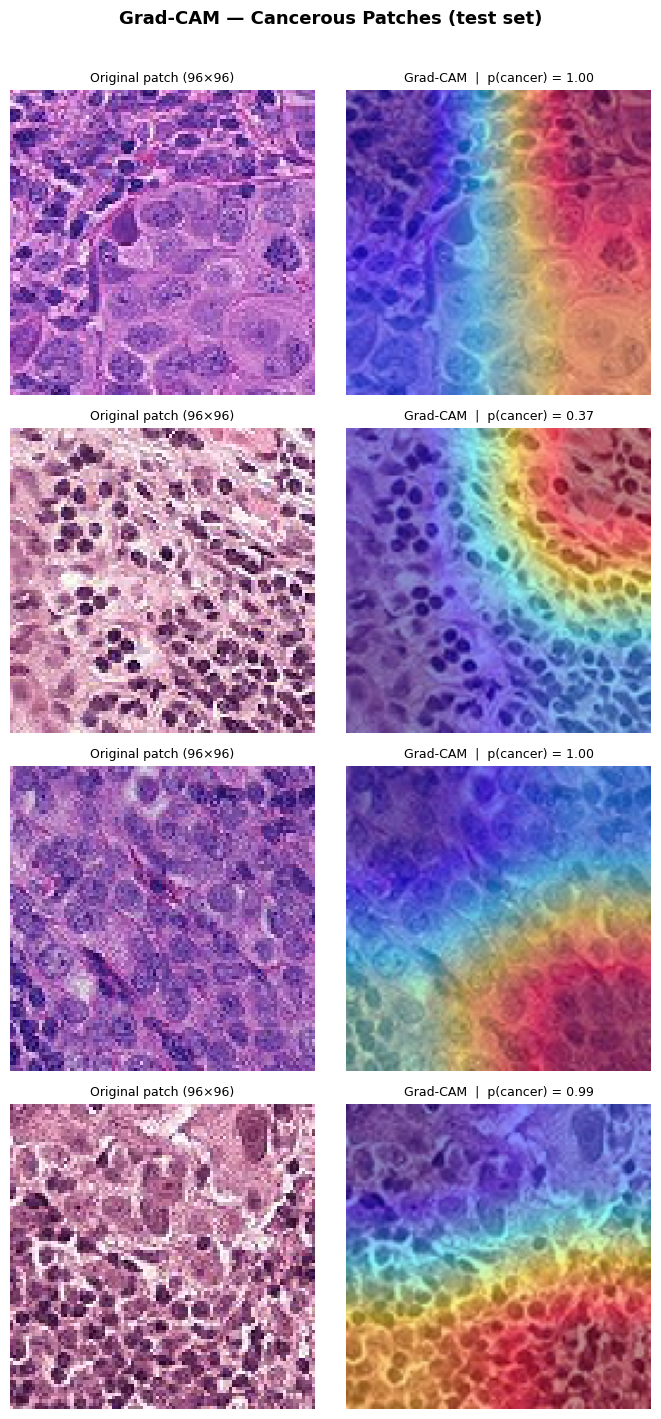

[OK] Saved: /kaggle/working/gradcam_non-cancerous.png


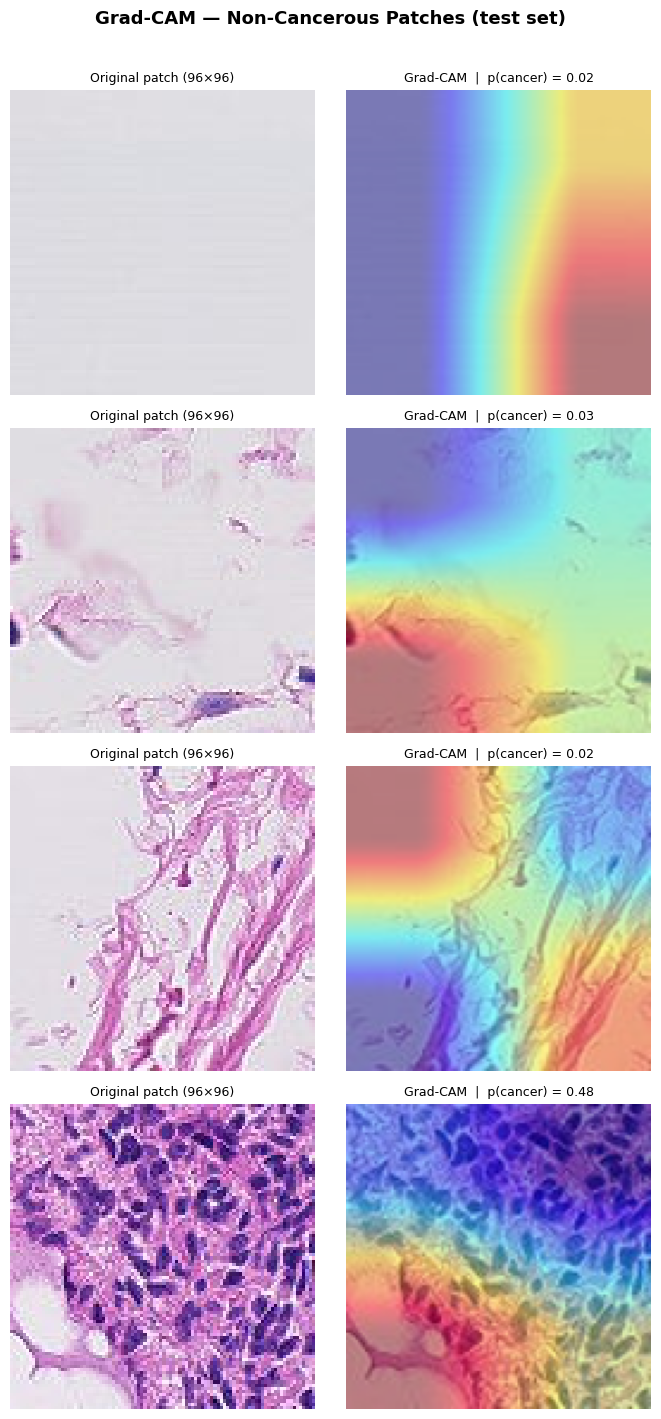

In [22]:
if gradcam is None:
    print("[SKIP] Grad-CAM not available.")
else:
    # Use test set IDs (the model has never seen these during training)
    cancerous_ids     = test_df[test_df['label'] == 1]['id'].tolist()
    non_cancerous_ids = test_df[test_df['label'] == 0]['id'].tolist()
    print(f"Test set — Cancerous: {len(cancerous_ids):,}  |  Non-cancerous: {len(non_cancerous_ids):,}")

    def run_panel(img_ids, label_name, n=4):
        fig, axes = plt.subplots(n, 2, figsize=(7, n * 3.5))
        fig.suptitle(f'Grad-CAM — {label_name} Patches (test set)',
                     fontsize=13, fontweight='bold', y=1.01)
        for i, img_id in enumerate(img_ids[:n]):
            try:
                tensor, pil_img  = load_for_gradcam(img_id)
                heatmap, score   = gradcam(tensor)
                overlay, orig    = overlay_heatmap(pil_img, heatmap)
            except Exception as e:
                print(f"[WARN] Panel row {i} failed: {e}")
                continue

            axes[i, 0].imshow(np.array(pil_img))
            axes[i, 0].set_title('Original patch (96×96)', fontsize=9)
            axes[i, 0].axis('off')

            axes[i, 1].imshow(overlay)
            axes[i, 1].set_title(f'Grad-CAM  |  p(cancer) = {score:.2f}', fontsize=9)
            axes[i, 1].axis('off')

        plt.tight_layout()
        fname = os.path.join(WORK_DIR, f'gradcam_{label_name.lower().replace(" ","_")}.png')
        try:
            plt.savefig(fname, dpi=150, bbox_inches='tight')
            print(f"[OK] Saved: {fname}")
        except Exception as e:
            print(f"[WARN] Could not save {fname}: {e}")
        plt.show()

    run_panel(cancerous_ids,     'Cancerous',     n=4)
    run_panel(non_cancerous_ids, 'Non-Cancerous', n=4)


### 8.3 Side-by-Side Comparison Grid
**Primary portfolio image** — shows the model's spatial attention across both classes.

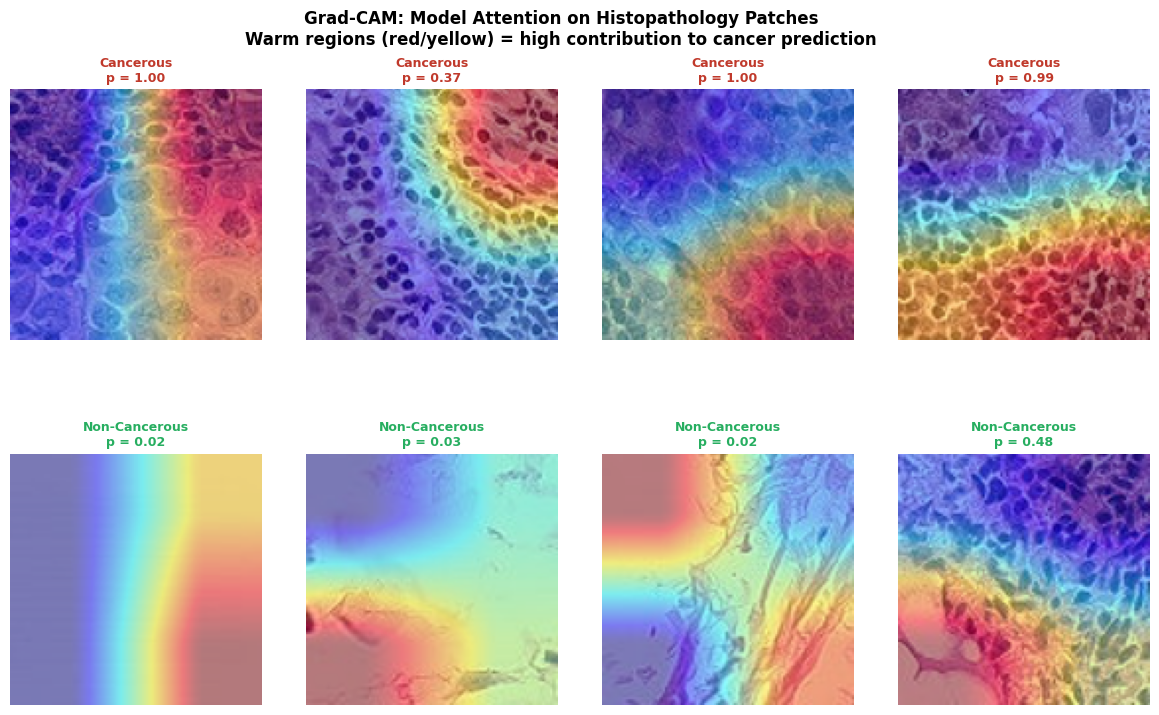

[OK] Saved: /kaggle/working/gradcam_comparison_grid.png  ← primary portfolio image


In [23]:
if gradcam is None:
    print("[SKIP] Grad-CAM not available.")
else:
    N = 4
    try:
        fig = plt.figure(figsize=(15, 8))
        fig.suptitle(
            'Grad-CAM: Model Attention on Histopathology Patches\n'
            'Warm regions (red/yellow) = high contribution to cancer prediction',
            fontsize=12, fontweight='bold'
        )
        gs = gridspec.GridSpec(2, N, figure=fig, hspace=0.45, wspace=0.08)

        for i, img_id in enumerate(cancerous_ids[:N]):
            try:
                tensor, pil_img = load_for_gradcam(img_id)
                heatmap, score  = gradcam(tensor)
                overlay, _      = overlay_heatmap(pil_img, heatmap)
                ax = fig.add_subplot(gs[0, i])
                ax.imshow(overlay)
                ax.set_title(f'Cancerous\np = {score:.2f}', fontsize=9,
                             color='#c0392b', fontweight='bold')
                ax.axis('off')
            except Exception as e:
                print(f"[WARN] Cancerous grid cell {i}: {e}")

        for i, img_id in enumerate(non_cancerous_ids[:N]):
            try:
                tensor, pil_img = load_for_gradcam(img_id)
                heatmap, score  = gradcam(tensor)
                overlay, _      = overlay_heatmap(pil_img, heatmap)
                ax = fig.add_subplot(gs[1, i])
                ax.imshow(overlay)
                ax.set_title(f'Non-Cancerous\np = {score:.2f}', fontsize=9,
                             color='#27ae60', fontweight='bold')
                ax.axis('off')
            except Exception as e:
                print(f"[WARN] Non-cancerous grid cell {i}: {e}")

        grid_path = os.path.join(WORK_DIR, 'gradcam_comparison_grid.png')
        plt.savefig(grid_path, dpi=180, bbox_inches='tight')
        plt.show()
        print(f"[OK] Saved: {grid_path}  ← primary portfolio image")

    except Exception as e:
        print(f"[WARN] Comparison grid failed: {e}")
        traceback.print_exc()


## 9. Results Summary

In [24]:
print("=" * 60)
print("  RESULTS SUMMARY — CustomCNN on PCam")
print("=" * 60)

# ── Dataset ───────────────────────────────────────────────────────────────────
print("\n[DATASET]")
print(f"  Total clean samples : {len(clean_df):,}")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"  {name:5s}: {len(df):,}  "
          f"(Cancerous: {(df['label']==1).sum():,} | "
          f"Non-cancerous: {(df['label']==0).sum():,})")

# ── Model ─────────────────────────────────────────────────────────────────────
print("\n[MODEL]")
print(f"  Architecture : CustomCNN (5 conv blocks + 2 FC layers)")
print(f"  Parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device used  : {actual_device}")

# ── Training ──────────────────────────────────────────────────────────────────
if history['train_f1']:
    print("\n[TRAINING]")
    print(f"  Epochs completed : {len(history['train_f1'])}")
    print(f"  Best val F1      : {max(history['val_f1']):.4f}  "
          f"(epoch {history['val_f1'].index(max(history['val_f1']))+1})")
    print(f"  Final LR         : {history['lr'][-1]:.2e}")

# ── Test metrics ──────────────────────────────────────────────────────────────
try:
    print("\n[TEST SET METRICS]")
    print(f"  Accuracy  : {accuracy_score(test_targets, test_preds):.4f}")
    print(f"  Precision : {precision_score(test_targets, test_preds, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(test_targets, test_preds, zero_division=0):.4f}")
    print(f"  F1 Score  : {f1_score(test_targets, test_preds, zero_division=0):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(test_targets, test_probs):.4f}")
except Exception as e:
    print(f"  [WARN] Could not print metrics: {e}")

# ── Output files ──────────────────────────────────────────────────────────────
print("\n[OUTPUT FILES — /kaggle/working/]")
expected = ['clean_train_labels.csv','train.csv','val.csv','test.csv',
            'custom_cnn_best.pth',
            'training_curves.png','evaluation_plots.png',
            'gradcam_cancerous.png','gradcam_non-cancerous.png',
            'gradcam_comparison_grid.png']
for fname in expected:
    fpath = os.path.join(WORK_DIR, fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  ✓  {fname:<40s} ({size_kb:.1f} KB)")
    else:
        print(f"  ✗  {fname:<40s} (not found)")

print("\n" + "=" * 60)


  RESULTS SUMMARY — CustomCNN on PCam

[DATASET]
  Total clean samples : 219,984
  Train: 153,988  (Cancerous: 62,382 | Non-cancerous: 91,606)
  Val  : 32,998  (Cancerous: 13,368 | Non-cancerous: 19,630)
  Test : 32,998  (Cancerous: 13,367 | Non-cancerous: 19,631)

[MODEL]
  Architecture : CustomCNN (5 conv blocks + 2 FC layers)
  Parameters   : 1,832,737
  Device used  : cpu

[TRAINING]
  Epochs completed : 26
  Best val F1      : 0.8164  (epoch 21)
  Final LR         : 2.50e-04

[TEST SET METRICS]
  Accuracy  : 0.8524
  Precision : 0.8155
  Recall    : 0.8216
  F1 Score  : 0.8185
  ROC-AUC   : 0.9207

[OUTPUT FILES — /kaggle/working/]
  ✓  clean_train_labels.csv                   (9237.6 KB)
  ✓  train.csv                                (6466.3 KB)
  ✓  val.csv                                  (1385.7 KB)
  ✓  test.csv                                 (1385.7 KB)
  ✓  custom_cnn_best.pth                      (7178.7 KB)
  ✓  training_curves.png                      (117.7 KB)
  ✓  eva

## 10. Confidence Score (p-value) Analysis — Clinical & Insurance Perspective

The model outputs a probability `p ∈ [0,1]` representing confidence that a patch
contains cancerous tissue. This is not just a classification score — in a real
clinical deployment, this number carries different weight depending on context:

- **For a pathologist:** `p` determines which patches need immediate review vs. can
  be triaged to lower priority. High-confidence predictions (p > 0.9 or p < 0.1)
  are candidates for AI-assisted auto-reporting; borderline predictions (0.4–0.6)
  are mandatory human review cases.

- **For a diagnostic lab:** The distribution of `p` across a slide's patches
  correlates with tumor burden — a slide with many high-p patches signals extensive
  involvement vs. a slide with one or two moderate-p patches.

- **For an insurance/payer system:** Misclassifications have asymmetric costs.
  A false negative (missed cancer, p low on a cancerous patch) is catastrophic —
  delayed treatment, worse outcomes, liability. A false positive (flagged as cancer
  when benign, p high on non-cancerous) triggers unnecessary downstream procedures
  (biopsies, imaging, specialist referrals), increasing costs and patient anxiety.
  The p-distribution analysis reveals *how many* predictions fall into each risk tier.

The following analysis examines:
1. Distribution of p across the full test set
2. Accuracy, FP rate, and FN rate broken down by confidence tier
3. The "gray zone" — predictions between 0.3–0.7 that require human review
4. Clinical decision tiers: auto-approve / refer / urgent

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# ─────────────────────────────────────────────────────────────────────────────
# RE-RUN INFERENCE ON TEST SET TO COLLECT RAW PROBABILITIES
# (Skip this block if test_probs already exists from the evaluation cell)
# ─────────────────────────────────────────────────────────────────────────────
import torch

if 'test_probs' not in dir() or len(test_probs) == 0:
    print("[INFO] Re-running inference to collect probabilities...")
    model.eval()
    _probs, _preds, _targets = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            try:
                images = images.float().to(actual_device)
                out    = model(images).view(-1).cpu().numpy()
                _probs.extend(out)
                _preds.extend((out > 0.5).astype(int))
                _targets.extend(labels.numpy().astype(int))
            except Exception as e:
                print(f"[WARN] batch error: {e}")
                continue
    test_probs   = np.array(_probs)
    test_preds   = np.array(_preds)
    test_targets = np.array(_targets)
    print(f"[OK] Collected {len(test_probs):,} predictions")
else:
    print(f"[OK] Using existing test_probs ({len(test_probs):,} samples)")

# Build a clean dataframe for all downstream analysis
results_df = pd.DataFrame({
    'true_label':  test_targets,           # 0 = non-cancerous, 1 = cancerous
    'pred_label':  test_preds,             # 0/1 at threshold 0.5
    'p':           test_probs,             # raw sigmoid probability
})

# Outcome categories
results_df['outcome'] = 'TN'
results_df.loc[(results_df.true_label==1) & (results_df.pred_label==1), 'outcome'] = 'TP'
results_df.loc[(results_df.true_label==0) & (results_df.pred_label==1), 'outcome'] = 'FP'
results_df.loc[(results_df.true_label==1) & (results_df.pred_label==0), 'outcome'] = 'FN'

print(f"\nOutcome counts:")
print(results_df['outcome'].value_counts().to_string())
print(f"\nTotal test samples: {len(results_df):,}")

[OK] Using existing test_probs (32,998 samples)

Outcome counts:
outcome
TN    17146
TP    10982
FP     2485
FN     2385

Total test samples: 32,998


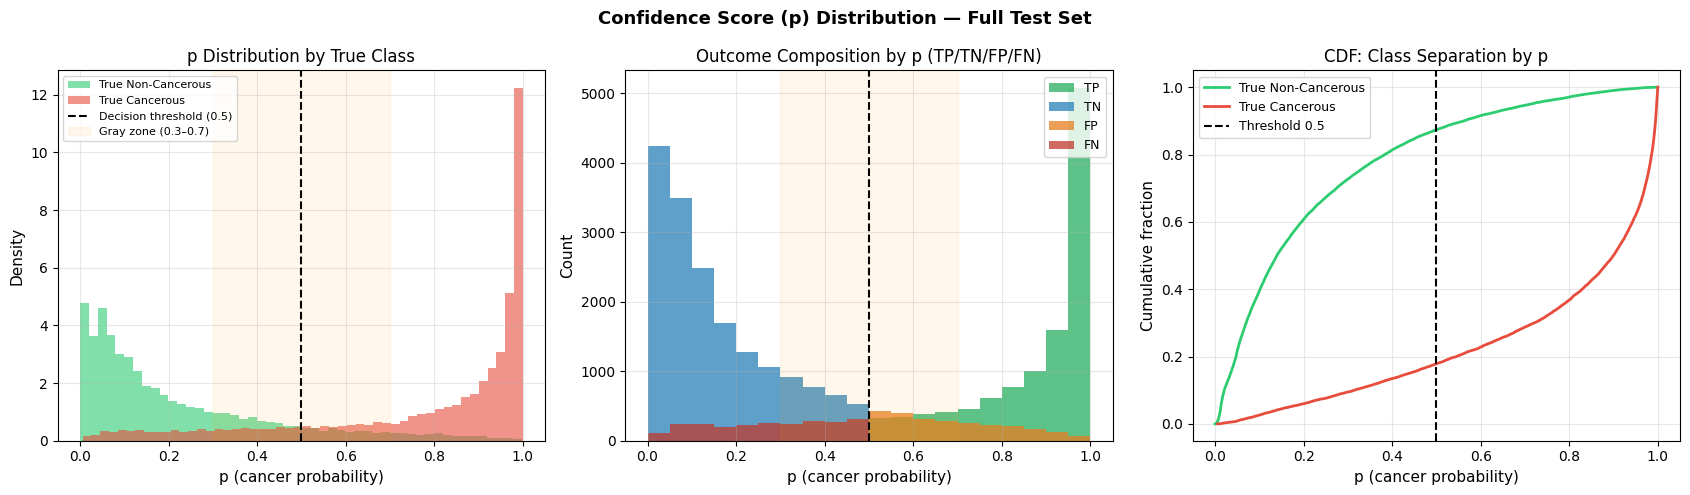

[OK] Saved: confidence_distribution.png


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION A — P-SCORE DISTRIBUTION
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Confidence Score (p) Distribution — Full Test Set',
             fontsize=13, fontweight='bold')

# ── A1: Full distribution ─────────────────────────────────────────────────────
ax = axes[0]
ax.hist(results_df[results_df.true_label==0]['p'], bins=50, alpha=0.6,
        color='#2ecc71', label='True Non-Cancerous', density=True)
ax.hist(results_df[results_df.true_label==1]['p'], bins=50, alpha=0.6,
        color='#e74c3c', label='True Cancerous', density=True)
ax.axvline(0.5,  color='black',  lw=1.5, linestyle='--', label='Decision threshold (0.5)')
ax.axvspan(0.3, 0.7, alpha=0.08, color='orange', label='Gray zone (0.3–0.7)')
ax.set_xlabel('p (cancer probability)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('p Distribution by True Class')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── A2: Stacked outcome composition across p ──────────────────────────────────
ax = axes[1]
bins   = np.arange(0, 1.05, 0.05)
colors = {'TP':'#27ae60','TN':'#2980b9','FP':'#e67e22','FN':'#c0392b'}
for outcome, color in colors.items():
    sub = results_df[results_df.outcome == outcome]['p']
    ax.hist(sub, bins=bins, alpha=0.75, color=color, label=outcome)
ax.axvline(0.5, color='black', lw=1.5, linestyle='--')
ax.axvspan(0.3, 0.7, alpha=0.08, color='orange')
ax.set_xlabel('p (cancer probability)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Outcome Composition by p (TP/TN/FP/FN)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── A3: CDF separation ────────────────────────────────────────────────────────
ax = axes[2]
p_neg = np.sort(results_df[results_df.true_label==0]['p'])
p_pos = np.sort(results_df[results_df.true_label==1]['p'])
ax.plot(p_neg, np.linspace(0,1,len(p_neg)), color='#2ecc71', lw=2, label='True Non-Cancerous')
ax.plot(p_pos, np.linspace(0,1,len(p_pos)), color='#e74c3c', lw=2, label='True Cancerous')
ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Threshold 0.5')
ax.set_xlabel('p (cancer probability)', fontsize=11)
ax.set_ylabel('Cumulative fraction', fontsize=11)
ax.set_title('CDF: Class Separation by p')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Saved: confidence_distribution.png")

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION B — TIERED CONFIDENCE ANALYSIS
# Clinical tiers: High confidence negative | Uncertain | High confidence positive
# ─────────────────────────────────────────────────────────────────────────────

# Define tiers
bins_conf  = [0.0, 0.10, 0.30, 0.50, 0.70, 0.90, 1.001]
bin_labels = ['p < 0.10\n(Very confident\nnon-cancer)',
              '0.10–0.30\n(Probable\nnon-cancer)',
              '0.30–0.50\n(Uncertain\nnon-cancer)',
              '0.50–0.70\n(Uncertain\ncancer)',
              '0.70–0.90\n(Probable\ncancer)',
              'p ≥ 0.90\n(Very confident\ncancer)']

results_df['conf_tier'] = pd.cut(results_df['p'], bins=bins_conf, labels=bin_labels,
                                  right=False, include_lowest=True)

tier_stats = []
for tier in bin_labels:
    sub = results_df[results_df.conf_tier == tier]
    n   = len(sub)
    if n == 0:
        continue
    tp  = (sub.outcome == 'TP').sum()
    tn  = (sub.outcome == 'TN').sum()
    fp  = (sub.outcome == 'FP').sum()
    fn  = (sub.outcome == 'FN').sum()
    n_cancer     = (sub.true_label == 1).sum()
    n_noncancer  = (sub.true_label == 0).sum()
    accuracy     = (tp + tn) / n if n else 0
    fn_rate      = fn / (fn + tp) if (fn + tp) > 0 else 0  # miss rate (clinically critical)
    fp_rate      = fp / (fp + tn) if (fp + tn) > 0 else 0  # false alarm rate
    tier_stats.append({
        'Tier': tier.replace('\n', ' '),
        'N': n, 'N%': 100*n/len(results_df),
        'True Cancerous': n_cancer, 'True Non-Cancerous': n_noncancer,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Accuracy': accuracy,
        'Miss Rate (FN%)': fn_rate,      # % of actual cancers missed — clinically critical
        'False Alarm (FP%)': fp_rate,    # % of benign flagged as cancer — cost critical
    })

tier_df = pd.DataFrame(tier_stats)

print("=" * 90)
print("CONFIDENCE TIER BREAKDOWN")
print("=" * 90)
display_cols = ['Tier','N','N%','True Cancerous','True Non-Cancerous',
                'Accuracy','Miss Rate (FN%)','False Alarm (FP%)']
print(tier_df[display_cols].to_string(index=False, float_format='{:.3f}'.format))

CONFIDENCE TIER BREAKDOWN
                                Tier    N     N%  True Cancerous  True Non-Cancerous  Accuracy  Miss Rate (FN%)  False Alarm (FP%)
p < 0.10 (Very confident non-cancer) 8088 24.511             352                7736     0.956            1.000              0.000
     0.10–0.30 (Probable non-cancer) 7450 22.577             917                6533     0.877            1.000              0.000
    0.30–0.50 (Uncertain non-cancer) 3993 12.101            1116                2877     0.721            1.000              0.000
        0.50–0.70 (Uncertain cancer) 2886  8.746            1458                1428     0.505            0.000              1.000
         0.70–0.90 (Probable cancer) 3718 11.267            2854                 864     0.768            0.000              1.000
    p ≥ 0.90 (Very confident cancer) 6863 20.798            6670                 193     0.972            0.000              1.000


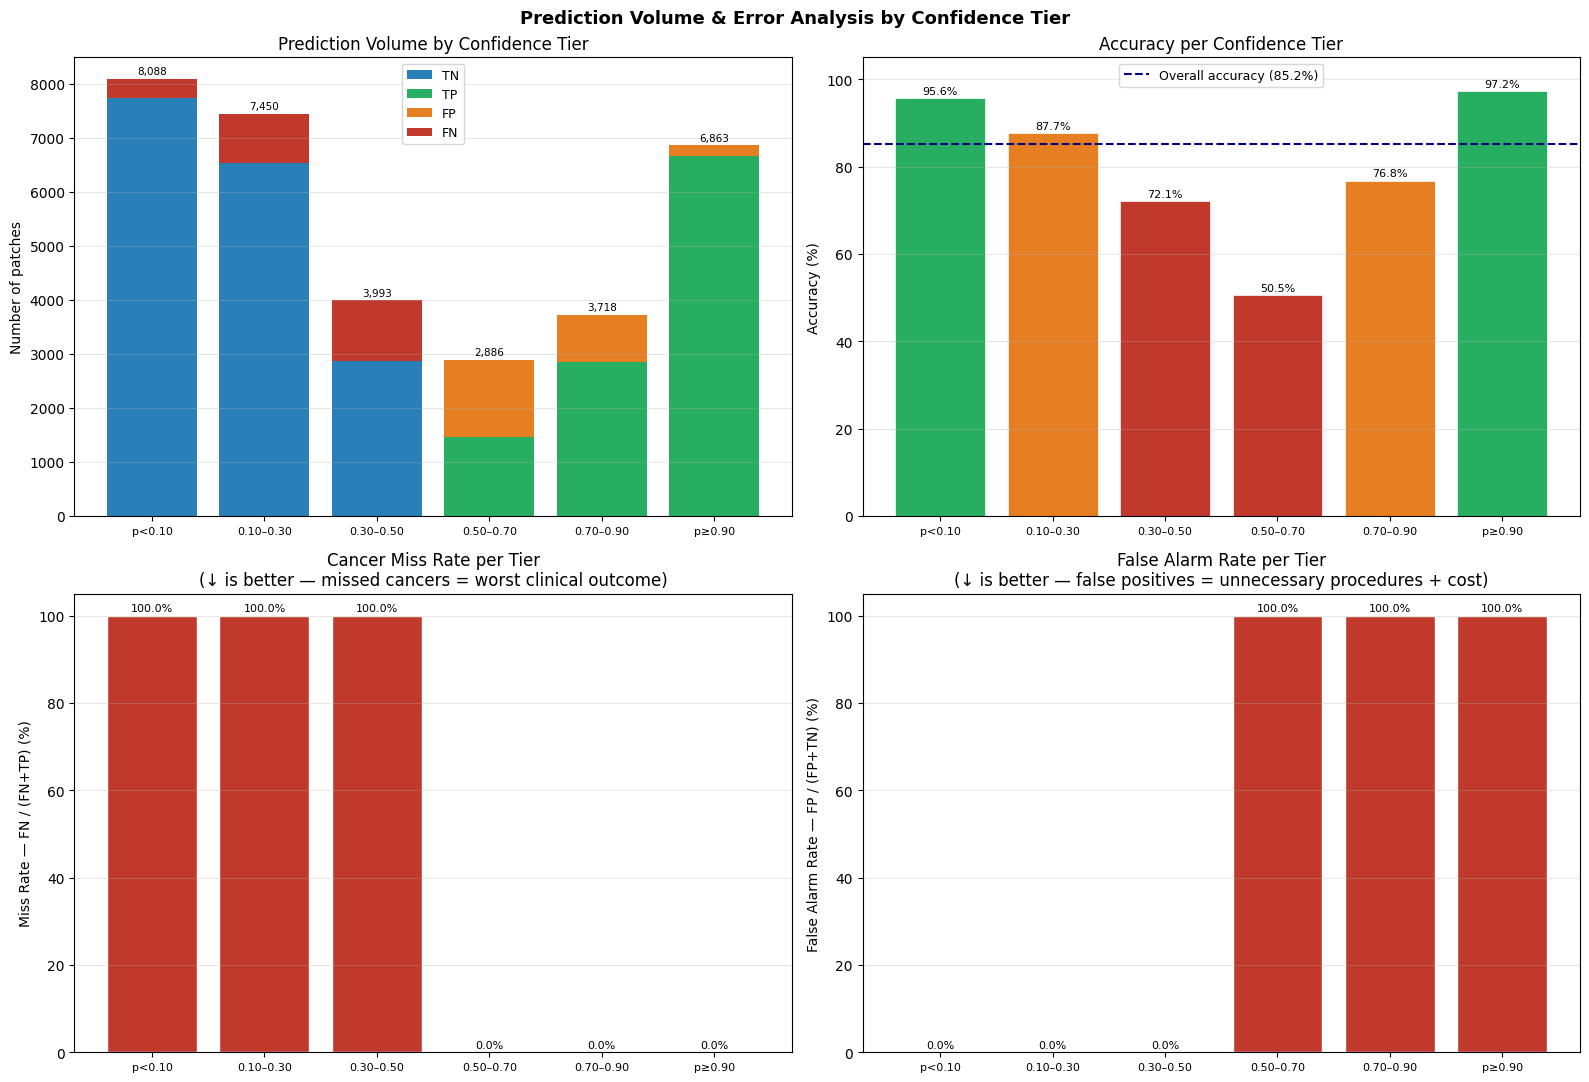

[OK] Saved: confidence_tier_analysis.png


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION C — RANGED BAR PLOT: PREDICTION VOLUME BY CONFIDENCE TIER
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Prediction Volume & Error Analysis by Confidence Tier',
             fontsize=13, fontweight='bold')

tier_labels_short = ['p<0.10', '0.10–0.30', '0.30–0.50', '0.50–0.70', '0.70–0.90', 'p≥0.90']
x = np.arange(len(tier_labels_short))

# ── C1: Volume bar — stacked TP/TN/FP/FN ────────────────────────────────────
ax = axes[0, 0]
tp_counts = tier_df['TP'].values
tn_counts = tier_df['TN'].values
fp_counts = tier_df['FP'].values
fn_counts = tier_df['FN'].values
b1 = ax.bar(x, tn_counts, color='#2980b9', label='TN')
b2 = ax.bar(x, tp_counts, bottom=tn_counts, color='#27ae60', label='TP')
b3 = ax.bar(x, fp_counts, bottom=tn_counts+tp_counts, color='#e67e22', label='FP')
b4 = ax.bar(x, fn_counts, bottom=tn_counts+tp_counts+fp_counts, color='#c0392b', label='FN')
ax.set_xticks(x); ax.set_xticklabels(tier_labels_short, fontsize=8)
ax.set_ylabel('Number of patches'); ax.set_title('Prediction Volume by Confidence Tier')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
# Annotate total per bar
for i, row in tier_df.iterrows():
    ax.text(i, row['N'] + 50, f"{int(row['N']):,}", ha='center', va='bottom', fontsize=7.5)

# ── C2: Accuracy per tier ────────────────────────────────────────────────────
ax = axes[0, 1]
bar_colors = ['#c0392b' if a < 0.75 else '#e67e22' if a < 0.90 else '#27ae60'
              for a in tier_df['Accuracy']]
bars = ax.bar(x, tier_df['Accuracy']*100, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(85.24, color='navy', lw=1.5, linestyle='--', label='Overall accuracy (85.2%)')
ax.set_xticks(x); ax.set_xticklabels(tier_labels_short, fontsize=8)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Accuracy per Confidence Tier')
ax.set_ylim(0, 105); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tier_df['Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

# ── C3: Miss rate (FN%) per tier — clinically most important ─────────────────
ax = axes[1, 0]
miss_colors = ['#c0392b' if r > 0.20 else '#e67e22' if r > 0.05 else '#27ae60'
               for r in tier_df['Miss Rate (FN%)']]
bars = ax.bar(x, tier_df['Miss Rate (FN%)']*100, color=miss_colors, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(tier_labels_short, fontsize=8)
ax.set_ylabel('Miss Rate — FN / (FN+TP) (%)'); 
ax.set_title('Cancer Miss Rate per Tier\n(↓ is better — missed cancers = worst clinical outcome)')
ax.set_ylim(0, 105); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tier_df['Miss Rate (FN%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

# ── C4: False alarm rate (FP%) per tier — cost/insurance important ────────────
ax = axes[1, 1]
fa_colors = ['#c0392b' if r > 0.30 else '#e67e22' if r > 0.10 else '#27ae60'
             for r in tier_df['False Alarm (FP%)']]
bars = ax.bar(x, tier_df['False Alarm (FP%)']*100, color=fa_colors, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(tier_labels_short, fontsize=8)
ax.set_ylabel('False Alarm Rate — FP / (FP+TN) (%)'); 
ax.set_title('False Alarm Rate per Tier\n(↓ is better — false positives = unnecessary procedures + cost)')
ax.set_ylim(0, 105); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tier_df['False Alarm (FP%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confidence_tier_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Saved: confidence_tier_analysis.png")

### Clinical Decision Zones

Based on the confidence analysis above, three clinical operating zones can be defined:

| Zone | p Range | Clinical Action | Analogy |
|------|---------|-----------------|---------|
| **Clear Negative** | p < 0.10 | AI auto-clears — no pathologist review needed | Low-risk screening lane |
| **Gray Zone** | 0.10–0.70 | Mandatory pathologist review | Borderline insurance claim — needs adjuster |
| **Clear Positive** | p > 0.90 | Immediate clinical escalation — flag for biopsy/treatment | High-priority claim |

For insurance underwriting and risk stratification: patches with p > 0.90 in a
significant proportion of a patient's slide would directly affect:
- Pre-authorization decisions for oncology procedures
- Risk tier assignment for life/health insurance premiums
- Clinical trial eligibility screening

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION D — HIGH-STAKES ZONE ANALYSIS (p ≥ 0.90 and p < 0.10)
# ─────────────────────────────────────────────────────────────────────────────

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

print("=" * 75)
print("HIGH-CONFIDENCE CANCER PREDICTIONS — Varying the positive threshold")
print("=" * 75)
print(f"{'Threshold':>10} {'N Flagged':>10} {'% of test':>10} {'Precision':>10} {'Recall':>10} {'FP among flagged':>18}")
print("-" * 75)
for thresh in thresholds:
    flagged   = results_df[results_df['p'] >= thresh]
    n         = len(flagged)
    pct       = 100 * n / len(results_df)
    if n == 0:
        print(f"{thresh:>10.2f} {'0':>10} {'0.00%':>10} {'N/A':>10} {'N/A':>10} {'N/A':>18}")
        continue
    tp_       = (flagged['outcome'] == 'TP').sum()
    fp_       = (flagged['outcome'] == 'FP').sum()
    precision = tp_ / (tp_ + fp_) if (tp_+fp_) > 0 else 0
    # recall: TP flagged / all actual positives in test set
    all_pos   = (results_df['true_label'] == 1).sum()
    recall    = tp_ / all_pos if all_pos > 0 else 0
    fp_pct    = 100 * fp_ / n
    print(f"{thresh:>10.2f} {n:>10,} {pct:>9.2f}% {precision:>10.4f} {recall:>10.4f} {fp_pct:>17.2f}%")

print()
print("=" * 75)
print("HIGH-CONFIDENCE NON-CANCER — Varying the negative threshold")
print("=" * 75)
print(f"{'Threshold':>10} {'N Cleared':>10} {'% of test':>10} {'Specificity':>12} {'FN among cleared':>18}")
print("-" * 75)
neg_thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.01]
for thresh in neg_thresholds:
    cleared   = results_df[results_df['p'] < thresh]
    n         = len(cleared)
    pct       = 100 * n / len(results_df)
    if n == 0:
        continue
    tn_       = (cleared['outcome'] == 'TN').sum()
    fn_       = (cleared['outcome'] == 'FN').sum()
    specificity = tn_ / (tn_ + fn_) if (tn_+fn_) > 0 else 0
    fn_pct    = 100 * fn_ / n  # % of cleared patches that were actually cancerous — danger metric
    print(f"{thresh:>10.2f} {n:>10,} {pct:>9.2f}% {specificity:>12.4f} {fn_pct:>17.2f}%")

HIGH-CONFIDENCE CANCER PREDICTIONS — Varying the positive threshold
 Threshold  N Flagged  % of test  Precision     Recall   FP among flagged
---------------------------------------------------------------------------
      0.50     13,467     40.81%     0.8155     0.8216             18.45%
      0.60     11,976     36.29%     0.8616     0.7720             13.84%
      0.70     10,581     32.07%     0.9001     0.7125              9.99%
      0.80      9,021     27.34%     0.9364     0.6319              6.36%
      0.90      6,863     20.80%     0.9719     0.4990              2.81%
      0.95      5,151     15.61%     0.9860     0.3800              1.40%
      0.99      2,189      6.63%     0.9973     0.1633              0.27%

HIGH-CONFIDENCE NON-CANCER — Varying the negative threshold
 Threshold  N Cleared  % of test  Specificity   FN among cleared
---------------------------------------------------------------------------
      0.50     19,531     59.19%       0.8779             12.2

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION E — GRAY ZONE DEEP DIVE + COST ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

gray = results_df[(results_df['p'] >= 0.3) & (results_df['p'] < 0.7)]
high_conf = results_df[(results_df['p'] < 0.3) | (results_df['p'] >= 0.7)]
very_high_conf = results_df[(results_df['p'] < 0.1) | (results_df['p'] >= 0.9)]

print("=" * 60)
print("GRAY ZONE ANALYSIS (p between 0.30 and 0.70)")
print("=" * 60)
print(f"  Gray zone patches     : {len(gray):,}  ({100*len(gray)/len(results_df):.1f}% of test set)")
print(f"  High-conf patches     : {len(high_conf):,}  ({100*len(high_conf)/len(results_df):.1f}% of test set)")
print(f"  Very high-conf patches: {len(very_high_conf):,}  ({100*len(very_high_conf)/len(results_df):.1f}% of test set)")
print()
print("  Among gray zone patches:")
print(f"    True Cancerous    : {(gray.true_label==1).sum():,}  ({100*(gray.true_label==1).mean():.1f}%)")
print(f"    True Non-Cancerous: {(gray.true_label==0).sum():,}  ({100*(gray.true_label==0).mean():.1f}%)")
print(f"    TP: {(gray.outcome=='TP').sum():,}  TN: {(gray.outcome=='TN').sum():,}  "
      f"FP: {(gray.outcome=='FP').sum():,}  FN: {(gray.outcome=='FN').sum():,}")
print(f"    Accuracy in gray zone: {((gray.outcome=='TP')|(gray.outcome=='TN')).mean():.4f}")
print()

# ── Cost simulation (clinical/insurance) ─────────────────────────────────────
# Illustrative cost weights — not real figures, but directionally meaningful
COST_FN = 50000  # Missed cancer: delayed diagnosis, worse outcome, liability ($USD illustrative)
COST_FP = 3000   # False positive: unnecessary biopsy, imaging, specialist ($USD illustrative)
COST_TN = 0
COST_TP = 0

total_fn_cost = (results_df.outcome == 'FN').sum() * COST_FN
total_fp_cost = (results_df.outcome == 'FP').sum() * COST_FP
gray_fn_cost  = (gray.outcome == 'FN').sum() * COST_FN
gray_fp_cost  = (gray.outcome == 'FP').sum() * COST_FP

print("=" * 60)
print("ILLUSTRATIVE COST ANALYSIS (per test set of 32,998 patches)")
print("(Costs are illustrative order-of-magnitude estimates)")
print("=" * 60)
print(f"  Missed cancers (FN)       : {(results_df.outcome=='FN').sum():,}  × ${COST_FN:,} = ${total_fn_cost:,.0f}")
print(f"  False alarms (FP)         : {(results_df.outcome=='FP').sum():,}  × ${COST_FP:,}  = ${total_fp_cost:,.0f}")
print(f"  Total illustrative cost   : ${total_fn_cost + total_fp_cost:,.0f}")
print()
print(f"  Gray zone contribution:")
print(f"    FN cost from gray zone  : ${gray_fn_cost:,.0f}  ({100*gray_fn_cost/total_fn_cost:.1f}% of total FN cost)")
print(f"    FP cost from gray zone  : ${gray_fp_cost:,.0f}  ({100*gray_fp_cost/total_fp_cost:.1f}% of total FP cost)")
print()
print("  → Routing gray-zone patches to mandatory human review would")
print(f"    affect {len(gray):,} patches ({100*len(gray)/len(results_df):.1f}% workload increase)")
print("    but capture the majority of costly errors.")

GRAY ZONE ANALYSIS (p between 0.30 and 0.70)
  Gray zone patches     : 6,879  (20.8% of test set)
  High-conf patches     : 26,119  (79.2% of test set)
  Very high-conf patches: 14,951  (45.3% of test set)

  Among gray zone patches:
    True Cancerous    : 2,574  (37.4%)
    True Non-Cancerous: 4,305  (62.6%)
    TP: 1,458  TN: 2,877  FP: 1,428  FN: 1,116
    Accuracy in gray zone: 0.6302

ILLUSTRATIVE COST ANALYSIS (per test set of 32,998 patches)
(Costs are illustrative order-of-magnitude estimates)
  Missed cancers (FN)       : 2,385  × $50,000 = $119,250,000
  False alarms (FP)         : 2,485  × $3,000  = $7,455,000
  Total illustrative cost   : $126,705,000

  Gray zone contribution:
    FN cost from gray zone  : $55,800,000  (46.8% of total FN cost)
    FP cost from gray zone  : $4,284,000  (57.5% of total FP cost)

  → Routing gray-zone patches to mandatory human review would
    affect 6,879 patches (20.8% workload increase)
    but capture the majority of costly errors.


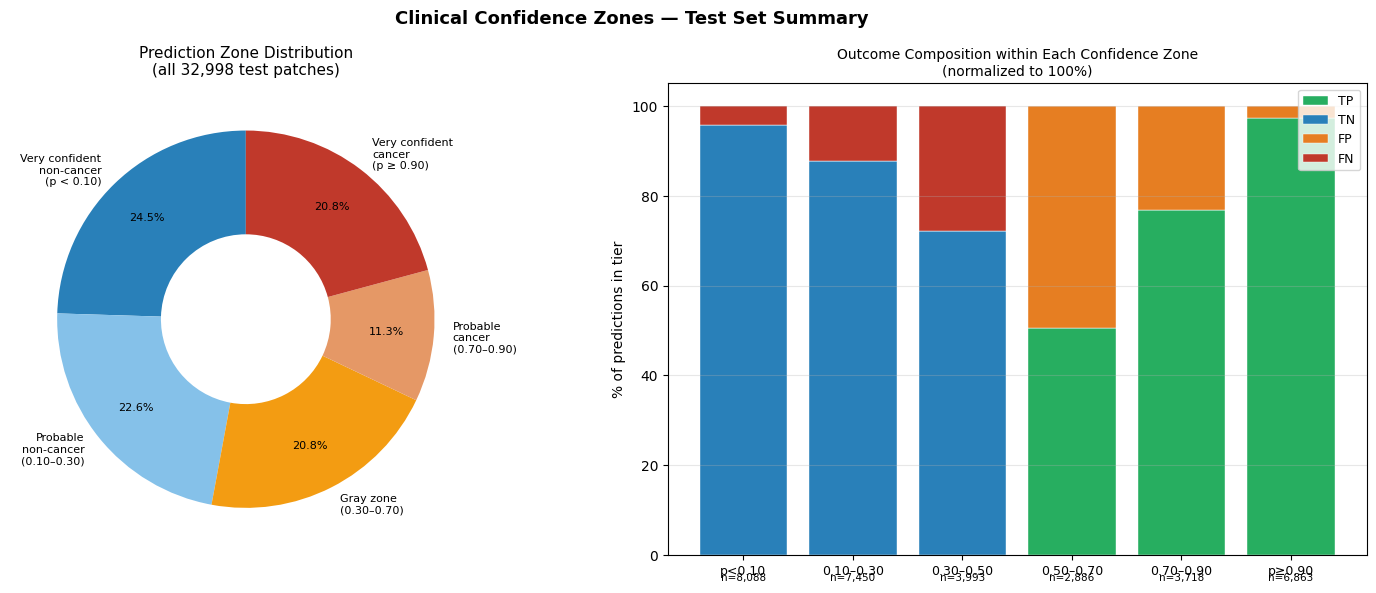

[OK] Saved: clinical_confidence_zones.png

All confidence analysis plots saved to /kaggle/working/


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION F — FINAL CONFIDENCE SUMMARY VISUAL
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Clinical Confidence Zones — Test Set Summary', fontsize=13, fontweight='bold')

# ── F1: Donut chart — prediction zone breakdown ───────────────────────────────
ax = axes[0]
zones = {
    'Very confident\nnon-cancer\n(p < 0.10)':  (results_df['p'] <  0.10).sum(),
    'Probable\nnon-cancer\n(0.10–0.30)':        ((results_df['p'] >= 0.10) & (results_df['p'] < 0.30)).sum(),
    'Gray zone\n(0.30–0.70)':                   ((results_df['p'] >= 0.30) & (results_df['p'] < 0.70)).sum(),
    'Probable\ncancer\n(0.70–0.90)':            ((results_df['p'] >= 0.70) & (results_df['p'] < 0.90)).sum(),
    'Very confident\ncancer\n(p ≥ 0.90)':       (results_df['p'] >= 0.90).sum(),
}
zone_colors = ['#2980b9','#85c1e9','#f39c12','#e59866','#c0392b']
wedges, texts, autotexts = ax.pie(
    zones.values(), labels=zones.keys(), colors=zone_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55))
for t in autotexts: t.set_fontsize(8)
for t in texts: t.set_fontsize(8)
ax.set_title('Prediction Zone Distribution\n(all 32,998 test patches)', fontsize=11)

# ── F2: Stacked bar — zone × outcome (normalized) ────────────────────────────
ax = axes[1]
zone_names_short = ['p<0.10', '0.10–0.30', '0.30–0.50', '0.50–0.70', '0.70–0.90', 'p≥0.90']
outcomes_order   = ['TP','TN','FP','FN']
out_colors       = {'TP':'#27ae60','TN':'#2980b9','FP':'#e67e22','FN':'#c0392b'}

bottom = np.zeros(len(tier_df))
for outcome in outcomes_order:
    col = outcome.lower() if outcome.lower() in ['tp','tn','fp','fn'] else outcome
    vals = tier_df[outcome].values / tier_df['N'].values * 100  # normalize to %
    bars = ax.bar(range(len(tier_df)), vals, bottom=bottom,
                  color=out_colors[outcome], label=outcome, edgecolor='white', linewidth=0.3)
    bottom += vals

ax.set_xticks(range(len(tier_df)))
ax.set_xticklabels(zone_names_short, fontsize=9)
ax.set_ylabel('% of predictions in tier')
ax.set_title('Outcome Composition within Each Confidence Zone\n(normalized to 100%)', fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 105); ax.grid(axis='y', alpha=0.3)
# Add N label below each bar
for i, row in tier_df.iterrows():
    ax.text(i, -4, f'n={int(row["N"]):,}', ha='center', va='top', fontsize=7.5, rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'clinical_confidence_zones.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Saved: clinical_confidence_zones.png")
print("\nAll confidence analysis plots saved to /kaggle/working/")